In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/images/high-dynamic-range-film-scene.jpg
/kaggle/input/images/danish-garden-flowers-closeup-low-260nw-2528388511.webp


In [2]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
low_contrast = cv2.imread("/kaggle/input/images/danish-garden-flowers-closeup-low-260nw-2528388511.webp", cv2.IMREAD_GRAYSCALE)
high_dynamic_range = cv2.imread("/kaggle/input/images/high-dynamic-range-film-scene.jpg", cv2.IMREAD_GRAYSCALE)

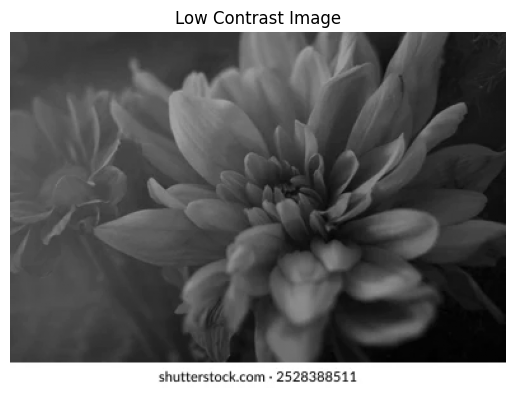

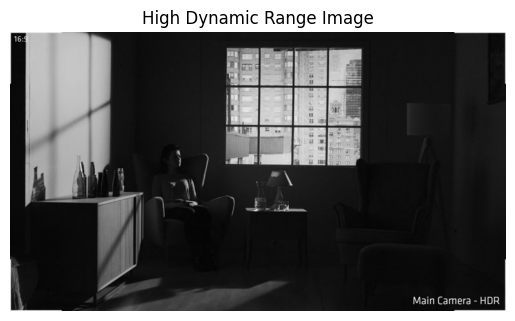

In [4]:
def see_image(img, title ):
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

see_image(low_contrast,"Low Contrast Image")
see_image(high_dynamic_range, "High Dynamic Range Image")

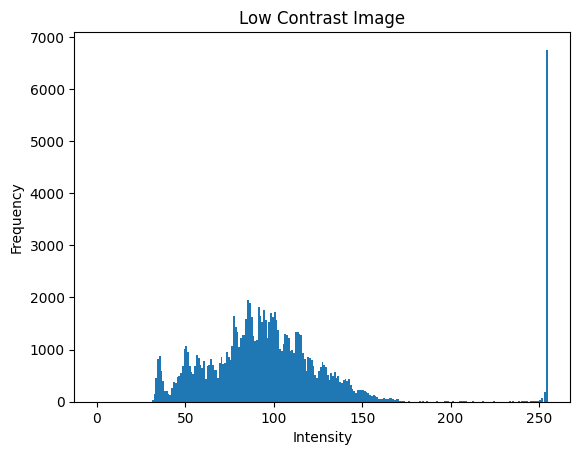

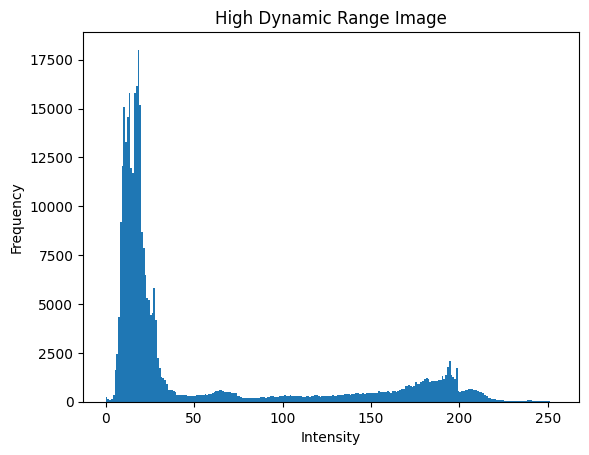

In [5]:
# intensity vs frequency plot
def plot_hist(img, title):
    plt.figure()
    plt.hist(img.ravel(), bins=255 , range=[0,255])
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.show()

plot_hist(low_contrast,"Low Contrast Image")
plot_hist(high_dynamic_range, "High Dynamic Range Image")

In [6]:
# Printing Stats 
def print_stats(img , name):
    print(f"{name} : min={img.min()} , max={img.max()} , mean = {img.mean():.2f}")

print_stats(low_contrast, "Low Contrast Image")
print_stats(high_dynamic_range, "Wide Dynamic Range Image")

Low Contrast Image : min=30 , max=255 , mean = 102.39
Wide Dynamic Range Image : min=0 , max=255 , mean = 52.98


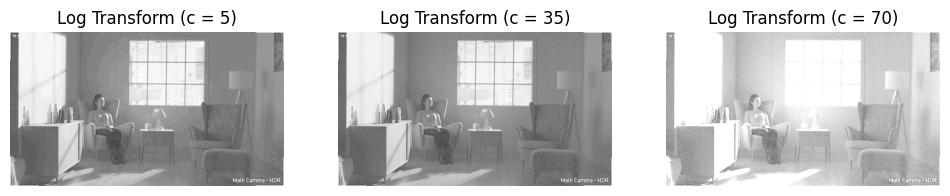

In [7]:
#Log transformation on image 
def log_transform(img, c):
    img = img.astype(np.float32) # log requires float values 
    log_img = c * np.log1p(img) # S = C * log(1 + R)
    log_img = np.clip(log_img, 0 , 255)  # clipping the values to come in that range so that all are 8 bit 
    return log_img.astype(np.uint8)


c_values = [5, 35, 70]

plt.figure(figsize=(12,4))
for i , c in enumerate(c_values): 
    plt.subplot(1 , 3 , i+1)
    plt.imshow(log_transform(high_dynamic_range,c), cmap="gray")
    plt.title(f"Log Transform (c = {c})")
    plt.axis("off")
plt.show()

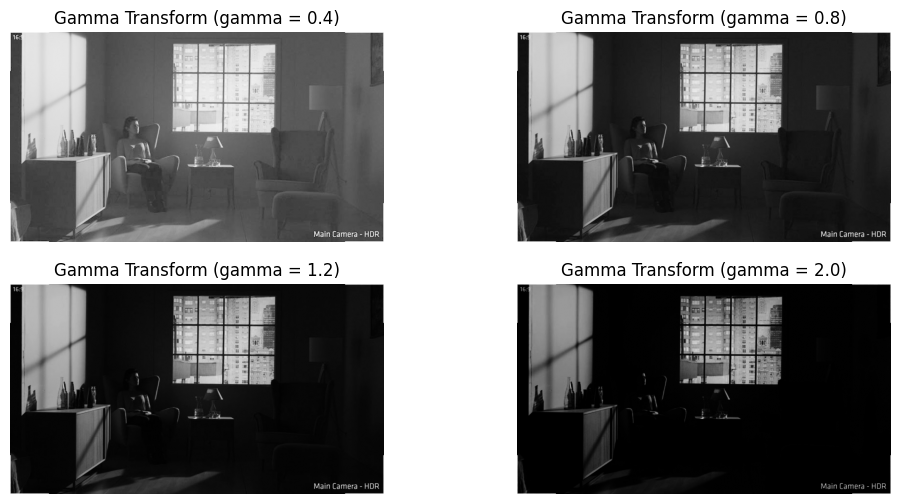

In [8]:
# Gamma Transform ( S = c. R ^ gamma)
def gamma_transform(img , gamma ): 
    img_norm = img/255.0    #normalising to avoid overexploding of values 
    gamma_img = np.power(img_norm , gamma) #gamma transform 
    return np.uint8(gamma_img*255)  #rescaling back to original form 
    
gammas = [0.4, 0.8, 1.2, 2.0]

plt.figure(figsize=(12,6))
for i , gamma in enumerate(gammas): 
    plt.subplot(2, 2, i+1)
    plt.imshow(gamma_transform(high_dynamic_range, gamma) , cmap="gray")
    plt.title(f"Gamma Transform (gamma = {gamma})")
    plt.axis("off")
plt.show()

therefore, lower values of gamma lighten the image whereas higher values of gamma darken the image
- gamma < 1 : lightens
- gamma > 1 : darkens
- gamma == 1 : no change 

In [9]:
# contrast stretching using a piecewise linear function
def contrast_stretch(img, r1, r2, s1, s2):
    stretched = np.zeroes_like(img, dtype=np.float32)
    L = 256

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            r = img[i,j]

            if r < r1 : 
                stretched[i,j] = (s1/r1) * r
            elif r <= r2: 
                stretched[i,j] = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1 
            else: 
                stretched[i,j] = ((L - 1 - s2)/ (L - 1 - r2)) * (r - r2) + s2

    return stretched.astype(np.uint8)

In [10]:
#contrast stretching function optimised version 
#this fn is faster cuz it is using numpy, so it cuts the middle man which is python interpreter and works a lot faster since numpy is written in C and fortran 
# this uses Boolean indexing in numpy instead of a python for loop 

def contrast_stretching_optimised(img, r1, r2, s1, s2):
    img = img.astype(np.float32)
    stretched = np.zeros_like(img)
    L = 256

    #creating 3 masks as per 3 conditions 
    mask1 = (img < r1)
    mask2 = (img >= r1) & (img <= r2)
    mask3 = (img > r2)

    stretched[mask1] = (s1/r1)*(img[mask1])
    stretched[mask2] = ((s2 - s1)/(r2 - r1)) * (img[mask2] - r1) + s1
    stretched[mask3] = ((L - 1 - s2) / (L - 1 - r2)) * (img[mask3] - r2) + s2

    return np.clip(stretched, 0 , 255).astype(np.uint8)

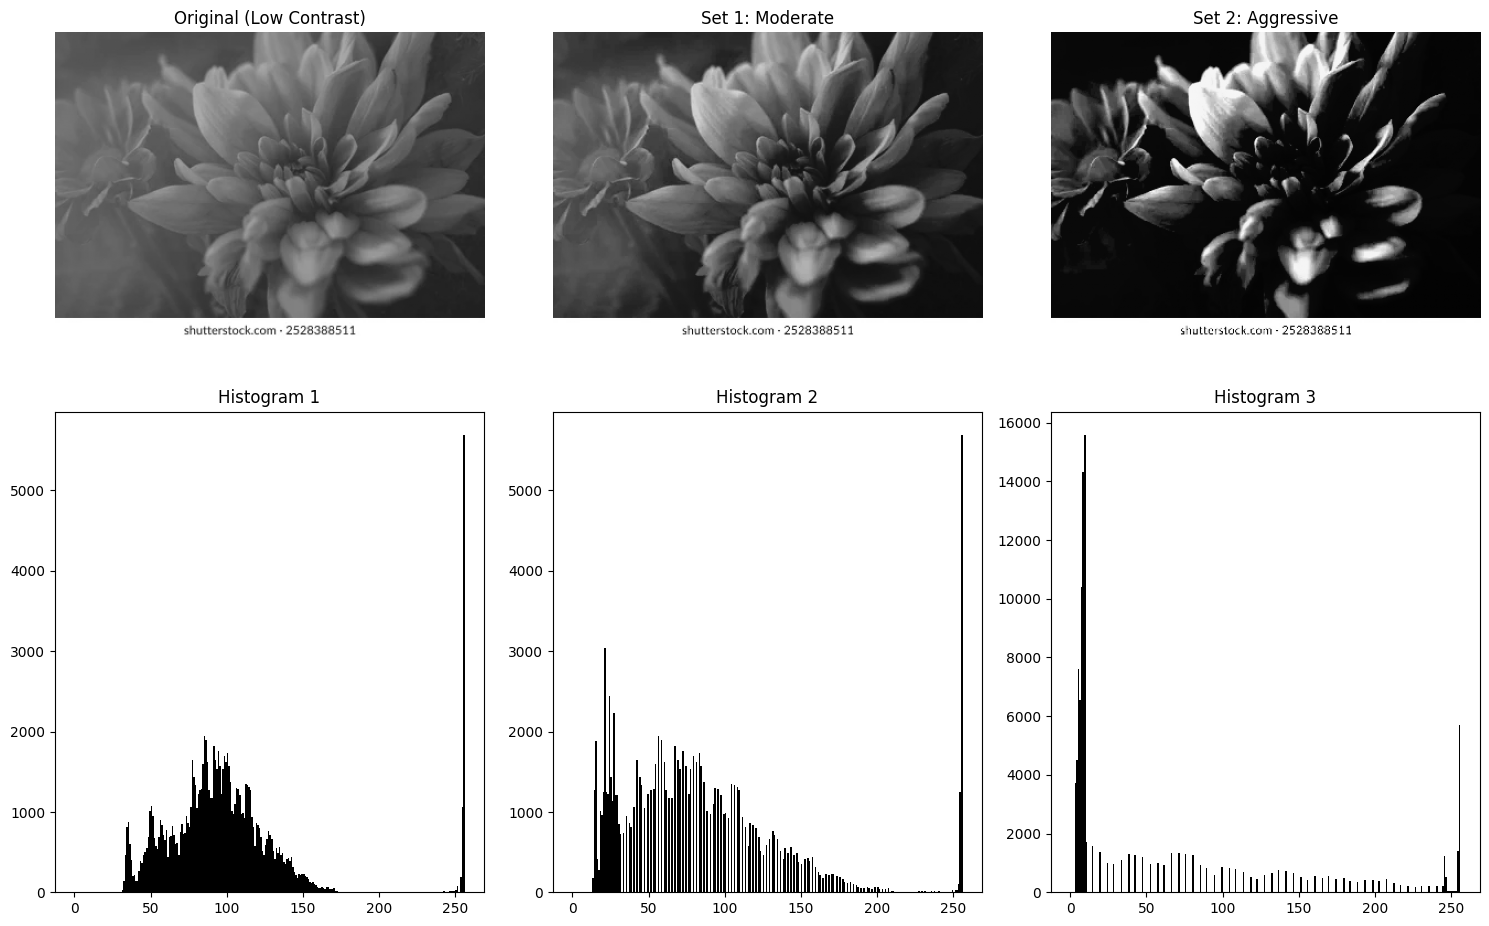

In [11]:
# Set 1: Moderate stretch
cs1 = contrast_stretching_optimised(low_contrast, 70, 180, 30, 225)
# Set 2: Aggressive stretch (r1 and r2 closer)
cs2 = contrast_stretching_optimised(low_contrast, 100, 150, 10, 245)

# Visualizing 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top Row- Images
images = [low_contrast, cs1, cs2]
titles = ["Original (Low Contrast)", "Set 1: Moderate", "Set 2: Aggressive"]

for i in range(3):
    axes[0, i].imshow(images[i], cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(titles[i])
    axes[0, i].axis('off')

# Bottom Row: Histograms
for i in range(3):
    axes[1, i].hist(images[i].ravel(), bins=256, range=(0, 256), color='black')
    axes[1, i].set_title(f"Histogram {i+1}")

plt.tight_layout()
plt.show()

In [12]:
#intensity level slicing 

# 1. Without bg
def slicing_without_bg(img, low, high):
    sliced = np.zeros_like(img)
    sliced[(img >= low) & (img <= high)] = 255
    return sliced

# 2. With bg 
def slicing_with_bg(img , low , high) : 
    sliced = img.copy()
    sliced[(img >= low) & (img <= high)] = 255
    return sliced 


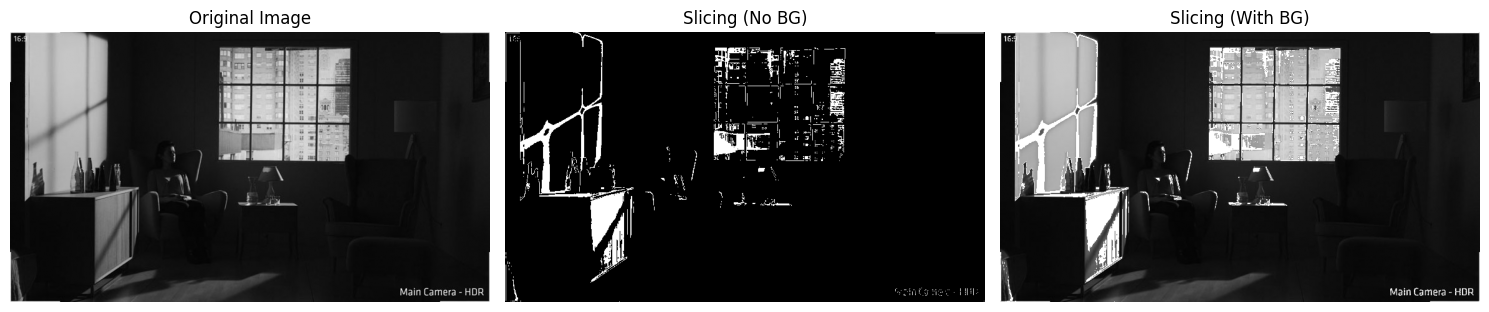

In [13]:
slice1 = slicing_without_bg(high_dynamic_range, 100, 150)
slice2 = slicing_with_bg(high_dynamic_range, 100, 150)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Original Image
axes[0].imshow(high_dynamic_range, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

# 2. Slicing without Background
axes[1].imshow(slice1, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Slicing (No BG)")
axes[1].axis("off")

# 3. Slicing with Background
axes[2].imshow(slice2, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Slicing (With BG)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [46]:
#extracting bit planes 
def bit_planes(img):
    planes = []
    for i in range(8):
        plane = (img >> i ) & 1 
        planes.append(plane * 255)

    return planes

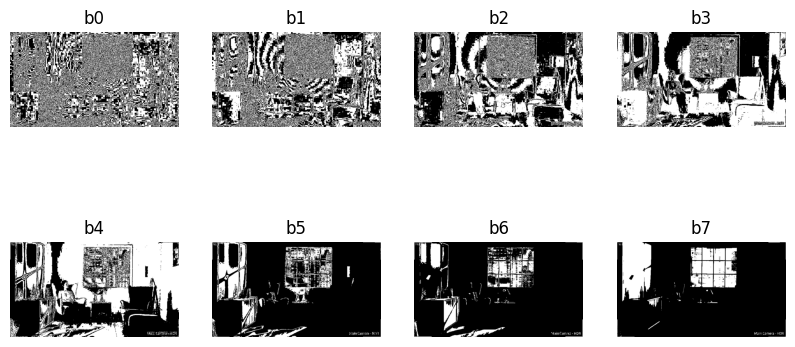

In [47]:
planes = bit_planes(high_dynamic_range)

plt.figure(figsize = (10,5))
for i in range(8): 
    plt.subplot(2, 4, i+1)
    plt.imshow(planes[i], cmap= 'gray')
    plt.title(f"b{i}")
    plt.axis("off")

plt.show()

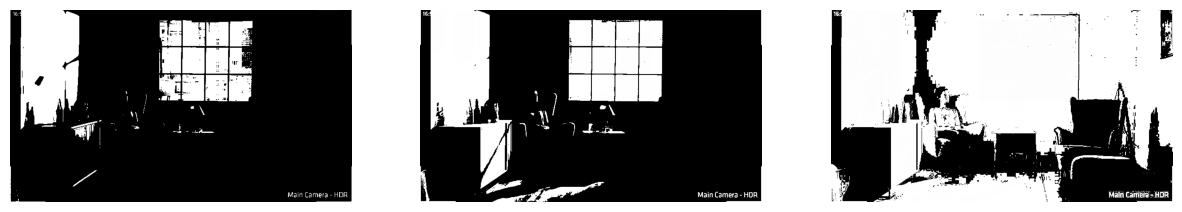

In [49]:
#reconstruction 
fig, axes = plt.subplots(1 , 3, figsize=(15,5))

# i. Only MSB plane (b7 )
b7 = planes[7]
axes[0].imshow(b7, cmap="gray")
axes[0].axis("off")

# ii. Top 2 planes (b7 + b6 )
b76 = planes[7] + planes[6]
axes[1].imshow(b76, cmap="gray")
axes[1].axis("off")

# iii. Top 4 planes (b7 to b4 )
b74 = planes[7] + planes[6] + planes[5] + planes[4]
axes[2].imshow(b74, cmap="gray")
axes[2].axis("off")

plt.show()

In [50]:
#MSE calculation 
def mse(original , reconstructed):
    original = original.astype(np.float32)
    reconstructed = reconstructed.astype(np.float32)
    return np.mean((original - reconstructed) ** 2)

In [52]:
# The corrected math for your variables:
b7_final = (planes[7] / 255) * 128
b76_final = ((planes[7] / 255) * 128) + ((planes[6] / 255) * 64)
b74_final = ((planes[7] / 255) * 128) + ((planes[6] / 255) * 64) + \
            ((planes[5] / 255) * 32) + ((planes[4] / 255) * 16)

# Now calculate MSE using these 'final' versions

In [53]:
print("MSE b7:", mse(high_dynamic_range, b7_final))
print("MSE b7+b6:", mse(high_dynamic_range, b76_final))
print("MSE b7-b4:", mse(high_dynamic_range, b74_final))


MSE b7: 1436.743
MSE b7+b6: 622.3194
MSE b7-b4: 78.70732


### Why do Higher Planes ($b_7, b_6, b_5$) look like the image?
These bits are the "Major Contributors." If we flip $b_7$, the brightness of that pixel changes by 128 units. That is the difference between a dark shadow and a bright mid-tone.Therefore, these planes contain the "structure" and "edges" of the objects.

### Why do Lower Planes ($b_0, b_1, b_2$) look like noise?
These bits are the "Minor Tweaks."  $b_0$ only changes the brightness by 1 unit. This is smaller than what the human eye can typically perceive.
- Sensor Noise: Digital sensors are sensitive to heat and electronic interference. This causes random fluctuations of $\pm 1$ or $\pm 2$ in the pixel value.
- The Result: Because these fluctuations are random, the $b_0$ plane looks like "snow" or "static" on an old TV. It contains no recognizable shapes, just the random "chatter" of the camera.